## ***SCRIPT PARA EL CALCULO SEGUN LA TEORIA DE PERFILES DELGADOS***
En este script se calculan varios parametros siguiendo la analogia del perfil a la deformada de una viga en voladizo

### Modelado de la Viga en Voladizo
Se ha modelado la geometría del perfil delgado como una viga en voladizo con tres tramos:
- **Primer tramo (0 a 7.8 cm):** Fijo, sin flexión.
- **Segundo tramo (7.8 a 16.8 cm):** Flexible, con una flexión parabólica controlada por un factor de flexión (`flex_factor`).
- **Tercer tramo (16.8 a 20 cm):** Recto, continuando con la pendiente del final del segundo tramo.

Longitud de cuerda total de la viga: 20.000 cm
Rango de x: [0.000, 20.000] cm
Rango de y (camber): [-1.732, 0.000] cm


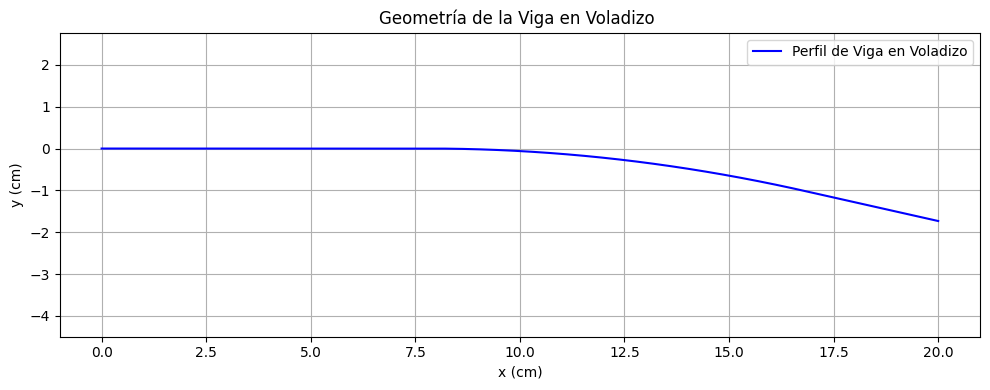

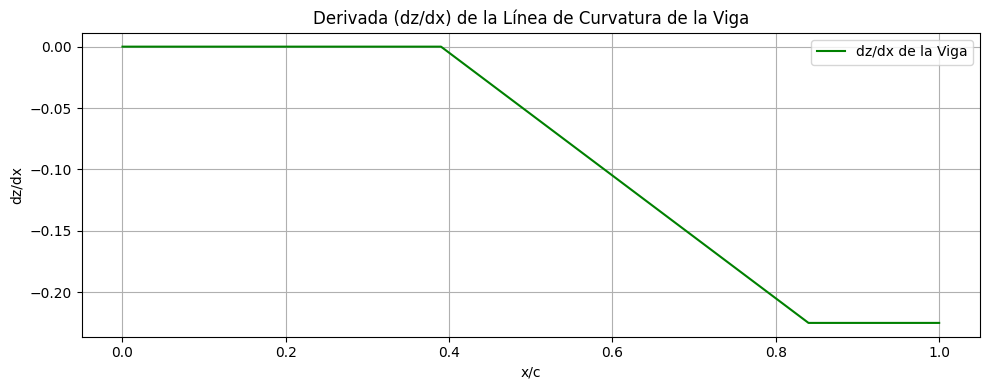

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def generate_cantilever_beam_data(L1, L2, L3, flex_factor, num_points_per_section=100):

    # Sección 1: Tramo rígido
    # Usamos endpoint=True para cerrar bien el tramo
    x1 = np.linspace(0, L1, num_points_per_section, endpoint=True)
    y1 = np.zeros_like(x1)
    dzdx1 = np.zeros_like(x1)

    # Sección 2: Tramo curvo
    # Al poner endpoint=True, el último punto será exactamente el final de L2
    x2_prime = np.linspace(0, L2, num_points_per_section, endpoint=True)
    x2 = x2_prime + L1
    y_flex_relative = -flex_factor * x2_prime**2 / 2
    dzdx_flex_relative = -flex_factor * x2_prime
    y2 = y_flex_relative
    dzdx2 = dzdx_flex_relative

    # Guardamos los valores EXACTOS al final del tramo 2
    y_at_end_L2 = y_flex_relative[-1]
    dzdx_at_end_L2 = dzdx_flex_relative[-1]

    # Sección 3: Tramo recto
    # Para evitar duplicar el punto de unión (L1 + L2), definimos los puntos
    # desde el primer paso posterior hasta el final de L3.
    x3_prime_completo = np.linspace(0, L3, num_points_per_section, endpoint=True)
    dx3 = x3_prime_completo[1] - x3_prime_completo[0] # Tamaño del paso numérico

    # Empezamos el tramo 3 un paso adelante para una transición limpia
    x3_prime = np.linspace(dx3, L3, num_points_per_section - 1, endpoint=True)
    x3 = x3_prime + L1 + L2

    # La altura se calcula con la ecuación de la recta partiendo del final real de L2
    y3 = y_at_end_L2 + dzdx_at_end_L2 * x3_prime
    dzdx3 = np.full_like(x3, dzdx_at_end_L2)

    # Combina todos los puntos y asegura el ordenamiento por x
    x_combined = np.concatenate((x1, x2, x3))
    y_combined = np.concatenate((y1, y2, y3))
    dzdx_combined = np.concatenate((dzdx1, dzdx2, dzdx3))

    sort_indices = np.argsort(x_combined)
    x_beam = x_combined[sort_indices]
    y_beam = y_combined[sort_indices]
    dzdx_beam = dzdx_combined[sort_indices]

    c_beam = L1 + L2 + L3
    return x_beam, y_beam, dzdx_beam, c_beam

# --- Definición de parámetros de la viga ---
L1_beam = 7.8  # cm
L2_beam = 9    # cm
L3_beam = 3.2  # cm
flex_factor_beam = 0.025
num_points = 200

# Generar los datos corregidos
x_beam, y_beam, dzdx_beam, c_beam = generate_cantilever_beam_data(
    L1_beam, L2_beam, L3_beam, flex_factor_beam, num_points_per_section=num_points//3
)

print(f"Longitud de cuerda total de la viga: {c_beam:.3f} cm")
print(f"Rango de x: [{x_beam.min():.3f}, {x_beam.max():.3f}] cm")
print(f"Rango de y (camber): [{y_beam.min():.3f}, {y_beam.max():.3f}] cm")

# Gráfico del perfil de la viga (Verás que el quiebre ha desaparecido)
plt.figure(figsize=(10, 4))
plt.plot(x_beam, y_beam, 'b-', label='Perfil de Viga en Voladizo')
plt.title('Geometría de la Viga en Voladizo ')
plt.xlabel('x (cm)')
plt.ylabel('y (cm)')
plt.grid(True)
plt.legend()
plt.axis('equal')
plt.tight_layout()
plt.show()

# Gráfico de la pendiente dzdx
plt.figure(figsize=(10, 4))
plt.plot(x_beam / c_beam, dzdx_beam, 'g-', label='dz/dx de la Viga')
plt.title('Derivada (dz/dx) de la Línea de Curvatura de la Viga')
plt.xlabel('x/c')
plt.ylabel('dz/dx')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [2]:
import matplotlib.pyplot as plt

def pressure_coefficient_vs_x(alpha_list, Vinf, x, dzdx, c):
    """
    Calcula y grafica el coeficiente de presión (Cp) vs x/c para una lista de ángulos de ataque.

    Args:
        alpha_list (list): Lista de ángulos de ataque en grados.
        Vinf (float): Velocidad de la corriente libre.
        x (np.array): Coordenadas x de los puntos del perfil (sin normalizar).
        dzdx (np.array): Pendiente de la línea de comba en las coordenadas x.
        c (float): Longitud de la cuerda del perfil.
    """
    plt.figure(figsize=(12, 8))
    for alpha in alpha_list:
        # Obtiene las características aerodinámicas para el alfa actual
        theta, gamma, cl, cm_c4, x_cp = airfoil_characteristics(alpha, Vinf, x, dzdx)

        # Se salta el primer punto (borde de ataque) debido a la singularidad en el cálculo de gamma
        # Usa la gamma dimensional devuelta por airfoil_characteristics
        Cp_upper = 1 - (1 + gamma[1:] / (2 * Vinf))**2
        Cp_lower = 1 - (1 - gamma[1:] / (2 * Vinf))**2

        # Coordenadas x correspondientes a gamma[1:], normalizadas por la longitud de la cuerda
        x_plot_normalized = x[1:] / c

        plt.plot(x_plot_normalized, Cp_upper, label=f'Cp Superior (α={alpha}°)')
        plt.plot(x_plot_normalized, Cp_lower, '--', label=f'Cp Inferior (α={alpha}°)')

    plt.title("Coeficiente de Presión Cp vs x/c para diferentes ángulos de ataque")
    plt.xlabel("x/c")
    plt.ylabel("Cp")
    plt.grid(True)
    plt.legend()
    plt.gca().invert_yaxis() # Invierte el eje y para seguir la convención aerodinámica (Cp más negativo hacia arriba)
    plt.tight_layout()
    plt.show()


### Análisis de la Viga en Voladizo con Teoría de Perfiles Delgados

Longitud de cuerda calculada para la viga: 20.000 cm

Resultados para la Viga a alpha = 0 grados:
Cl = 1.0188
Cm (c/4) = -0.1274
x_cp (x/c) = 0.3750


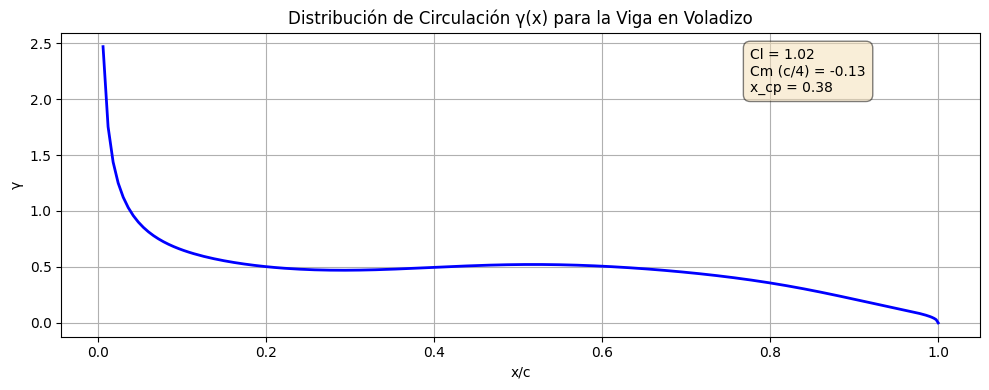

In [3]:
import numpy as np
import math
import matplotlib.pyplot as plt


def integrate(x, f): #integrates function f(x) from x[0] to x[-1]
    res = 0
    for i in range(len(x) - 1):
        dx = x[i + 1] - x[i]
        res += 0.5 * (f[i] + f[i + 1]) * dx
    return res


def airfoil_characteristics(alpha, Vinf, x, dzdx):
    alpha = alpha / 180 * math.pi
    c=x[-1] #cuerda
    theta = np.arccos(1.0 - 2.0*x/c) #vector de posiciones espaciales usando la transformación de Glauert

    num_coeficientes = 10
    A = np.zeros(num_coeficientes)
    A[0] =  alpha - (1/np.pi) * integrate(theta, dzdx)#coeficiente A0. Ayuda: Para la integral de dzdx en theta usa la función integrate de esta manera: integrate(theta, dzdx)
    for i in range(1, len(A)):
        A[i] = (2/np.pi)*integrate(theta, np.multiply(dzdx, np.cos(i * theta)))#coeficientes de orden superior. Ayuda: puedes usar np.multiply(dzdx, np.cos(i * theta)) para el integrando.

    # Genera la distribución gamma (skipping the leading edge)
    # Estrategia: generamos el vector con los valores de gamma(theta) con valor cero y lo vamos asignando en cada punto espacial (bucle i) sumando
    # todas las contribuciones An (bucle j)
    gamma = np.zeros(len(theta)) #es un vector que contendrá el valor de gamma en cada punto espacial theta
    for i in range(1, len(theta)): #empieza en 1 porque no contamos el primer punto theta[0] en el que existe una singularidad (infinito)
        gamma[i] =  A[0]* ((1+ math.cos(theta[i])) / ( math.sin(theta[i])))#.... aquí se añade A0
        for j in range(1, len(A)): #empieza en 1 porque empezamos con A1
            gamma[i]= gamma[i] + A[j] * math.sin(j * theta[i])#.... aquí se añade An
    gamma = 2 * Vinf * gamma
    # Completar las expresiones de los coeficientes según los apuntes
    cl = math.pi *(2*A[0]+A[1])
    cm_c4 = math.pi  / 4 *(A[2]-A[1])
    x_cp = 1 /4 *(1 + math.pi/cl * (A[1]-A[2]))

    return theta, gamma, cl, cm_c4, x_cp

# Use the generated beam data
# x_beam, y_beam, dzdx_beam, c_beam should be available from the previous cell execution

if 'x_beam' in locals() and 'y_beam' in locals() and 'dzdx_beam' in locals() and 'c_beam' in locals():
    # 1. Obtener x e y del perfil de la viga y su dzdx
    x_profile = x_beam
    y_profile = y_beam
    dzdx_profile = dzdx_beam

    # 2. Definir la cuerda (c)
    c_profile = c_beam
    print(f"Longitud de cuerda calculada para la viga: {c_profile:.3f} cm")

    # 3. Definir ángulo de ataque y velocidad
    alpha_beam = 0 # ángulo de ataque en grados
    Vinf_beam = 1 # velocidad en m/s

    # 4. Llamar a la función airfoil_characteristics con los datos de la viga
    # La función airfoil_characteristics espera 'x' normalizado (0 a c) para algunos cálculos internos.
    # El x_beam ya está comenzando en 0, lo cual es adecuado.
    x_profile_normalized_for_theory = x_profile - x_profile.min()

    [theta, gamma_profile, cl_profile, cm_c4_profile, x_cp_profile] = airfoil_characteristics(alpha_beam, Vinf_beam, x_profile_normalized_for_theory, dzdx_profile)

    # 5. Imprimir Cl y la distribución de circulación
    print(f"\nResultados para la Viga a alpha = {alpha_beam} grados:")
    print(f"Cl = {cl_profile:.4f}")
    print(f"Cm (c/4) = {cm_c4_profile:.4f}")
    print(f"x_cp (x/c) = {x_cp_profile:.4f}")

    plt.figure(figsize=(10, 4))
    # Plotear gamma contra x/c (normalized x)
    plt.plot(x_profile_normalized_for_theory[1:] / c_profile, gamma_profile[1:], 'b-', linewidth=2)
    plt.title("Distribución de Circulación γ(x) para la Viga en Voladizo")
    plt.xlabel("x/c")
    plt.ylabel("γ")
    plt.grid(True)

    # Add Cl, Cm, x_cp to the plot as text annotation
    textstr = f'Cl = {cl_profile:.2f}\nCm (c/4) = {cm_c4_profile:.2f}\nx_cp = {x_cp_profile:.2f}'
    props = dict(boxstyle='round,pad=0.5', facecolor='wheat', alpha=0.5)
    plt.text(0.75, 0.95, textstr, transform=plt.gca().transAxes, fontsize=10,
            verticalalignment='top', bbox=props)

    plt.tight_layout()
    plt.show()

else:
    print("Las variables de la viga necesarias para el análisis no están definidas. Por favor, asegúrate de haber ejecutado la celda anterior que genera la geometría de la viga.")


### Análisis de Coeficiente de Presión (Cp) para Diferentes Momentos de Flexión

Ahora, vamos a visualizar el coeficiente de presión a lo largo de la cuerda (`x/c`) para diferentes factores de flexión aplicados a la viga en voladizo. Esto nos permitirá entender cómo la deformación del perfil afecta la distribución de presiones, manteniendo el ángulo de ataque constante.

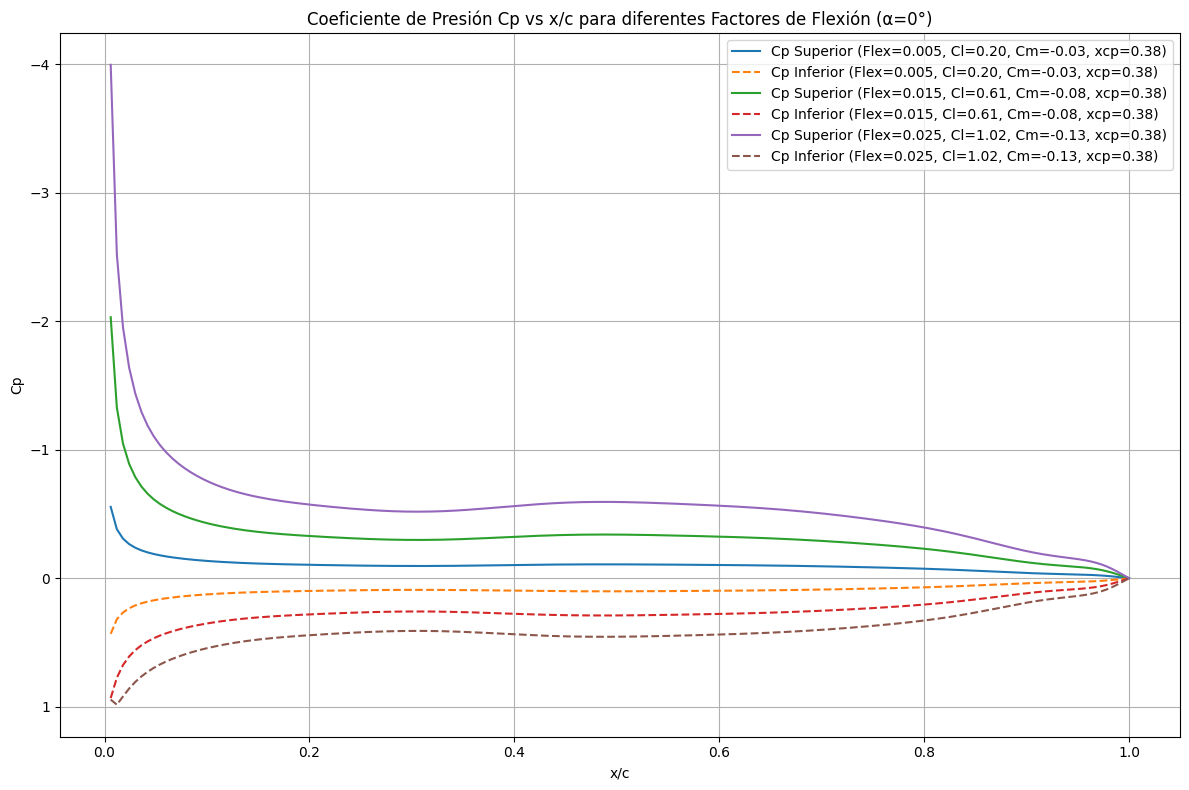

In [4]:
import numpy as np
import math
import matplotlib.pyplot as plt

def integrate(x, f): #integrates function f(x) from x[0] to x[-1]
    res = 0
    for i in range(len(x) - 1):
        dx = x[i + 1] - x[i]
        res += 0.5 * (f[i] + f[i + 1]) * dx
    return res

def airfoil_characteristics(alpha, Vinf, x, dzdx):
    alpha = alpha / 180 * math.pi
    c=x[-1] #cuerda
    theta = np.arccos(1.0 - 2.0*x/c) #vector de posiciones espaciales usando la transformación de Glauert

    num_coeficientes = 15
    A = np.zeros(num_coeficientes)
    A[0] =  alpha - (1/np.pi) * integrate(theta, dzdx)#coeficiente A0. Ayuda: Para la integral de dzdx en theta usa la función integrate de esta manera: integrate(theta, dzdx)
    for i in range(1, len(A)):
        A[i] = (2/np.pi)*integrate(theta, np.multiply(dzdx, np.cos(i * theta)))#coeficientes de orden superior. Ayuda: puedes usar np.multiply(dzdx, np.cos(i * theta)) para el integrando.

    gamma = np.zeros(len(theta))
    for i in range(1, len(theta)):
        gamma[i] =  A[0]* ((1+ math.cos(theta[i])) / ( math.sin(theta[i])))
        for j in range(1, len(A)): #empieza en 1 porque empezamos con A1
            gamma[i]= gamma[i] + A[j] * math.sin(j * theta[i])
    gamma = 2 * Vinf * gamma

    cl = math.pi *(2*A[0]+A[1])
    cm_c4 = math.pi  / 4 *(A[2]-A[1])
    x_cp = 1 /4 *(1 + math.pi/cl * (A[1]-A[2]))

    return theta, gamma, cl, cm_c4, x_cp

def generate_cantilever_beam_data(L1, L2, L3, flex_factor, num_points_per_section=100):
    """
    Genera las coordenadas x, y y dzdx para un modelo de viga en voladizo.

    Args:
        L1 (float): Longitud de la primera sección fija (cm).
        L2 (float): Longitud de la segunda sección flexible (cm).
        L3 (float): Longitud de la tercera sección recta (cm).
        flex_factor (float): Factor de curvatura para la sección flexible (ej., M / (E*I)).
        num_points_per_section (int): Número de puntos por sección.

    Returns:
        tuple: (x_beam, y_beam, dzdx_beam, c_beam)
            x_beam (np.array): Coordenadas x del perfil de la viga.
            y_beam (np.array): Coordenadas y del perfil de la viga (línea de comba).
            dzdx_beam (np.array): Pendiente de la línea de comba.
            c_beam (float): Longitud total de la cuerda.
    """

    # Sección 1: Tramo rígido
    # Usamos endpoint=True para cerrar bien el tramo
    x1 = np.linspace(0, L1, num_points_per_section, endpoint=True)
    y1 = np.zeros_like(x1)
    dzdx1 = np.zeros_like(x1)

    # Sección 2: Tramo curvo
    # Al poner endpoint=True, el último punto será exactamente el final de L2
    x2_prime = np.linspace(0, L2, num_points_per_section, endpoint=True)
    x2 = x2_prime + L1
    y_flex_relative = -flex_factor * x2_prime**2 / 2
    dzdx_flex_relative = -flex_factor * x2_prime
    y2 = y_flex_relative
    dzdx2 = dzdx_flex_relative

    # Guardamos los valores EXACTOS al final del tramo 2
    y_at_end_L2 = y_flex_relative[-1]
    dzdx_at_end_L2 = dzdx_flex_relative[-1]

    # Sección 3: Tramo recto
    # Para evitar duplicar el punto de unión (L1 + L2), definimos los puntos
    # desde el primer paso posterior hasta el final de L3.
    x3_prime_completo = np.linspace(0, L3, num_points_per_section, endpoint=True)
    dx3 = x3_prime_completo[1] - x3_prime_completo[0] # Tamaño del paso numérico

    # Empezamos el tramo 3 un paso adelante para una transición limpia
    x3_prime = np.linspace(dx3, L3, num_points_per_section - 1, endpoint=True)
    x3 = x3_prime + L1 + L2

    # La altura se calcula con la ecuación de la recta partiendo del final real de L2
    y3 = y_at_end_L2 + dzdx_at_end_L2 * x3_prime
    dzdx3 = np.full_like(x3, dzdx_at_end_L2)

    # Combina todos los puntos y asegura el ordenamiento por x
    x_combined = np.concatenate((x1, x2, x3))
    y_combined = np.concatenate((y1, y2, y3))
    dzdx_combined = np.concatenate((dzdx1, dzdx2, dzdx3))

    sort_indices = np.argsort(x_combined)
    x_beam = x_combined[sort_indices]
    y_beam = y_combined[sort_indices]
    dzdx_beam = dzdx_combined[sort_indices]

    c_beam = L1 + L2 + L3
    return x_beam, y_beam, dzdx_beam, c_beam

def plot_cp_for_different_flex_factors(flex_factor_list, alpha_val, Vinf, L1, L2, L3, num_points_per_section):
    """
    Calcula y grafica el coeficiente de presión (Cp) vs x/c para una lista de factores de flexión.

    Args:
        flex_factor_list (list): Lista de factores de flexión a simular.
        alpha_val (float): Ángulo de ataque constante en grados.
        Vinf (float): Velocidad de la corriente libre.
        L1 (float): Longitud de la primera sección fija (cm).
        L2 (float): Longitud de la segunda sección flexible (cm).
        L3 (float): Longitud de la tercera sección recta (cm).
        num_points_per_section (int): Número de puntos por sección para la generación de la viga.
    """
    plt.figure(figsize=(12, 8))
    for flex_factor in flex_factor_list:
        # Genera los datos de la viga para el factor de flexión actual
        x_beam_current, y_beam_current, dzdx_beam_current, c_beam_current = generate_cantilever_beam_data(L1, L2, L3, flex_factor, num_points_per_section)

        # Prepara los datos para la función airfoil_characteristics
        x_profile_normalized_for_theory = x_beam_current - x_beam_current.min()
        dzdx_profile = dzdx_beam_current
        c_profile = c_beam_current

        # Obtiene las características aerodinámicas para el factor de flexión actual (a alfa constante)
        theta, gamma, cl, cm_c4, x_cp = airfoil_characteristics(alpha_val, Vinf, x_profile_normalized_for_theory, dzdx_profile)

        # Calcula los valores de Cp
        # Se salta el primer punto (borde de ataque) debido a la singularidad en el cálculo de gamma
        Cp_upper = 1 - (1 + gamma[1:] / (2 * Vinf))**2
        Cp_lower = 1 - (1 - gamma[1:] / (2 * Vinf))**2

        # Coordenadas x correspondientes a gamma[1:], normalizadas por la longitud de la cuerda
        x_plot_normalized = x_profile_normalized_for_theory[1:] / c_profile

        plt.plot(x_plot_normalized, Cp_upper, label=f'Cp Superior (Flex={flex_factor}, Cl={cl:.2f}, Cm={cm_c4:.2f}, xcp={x_cp:.2f})')
        plt.plot(x_plot_normalized, Cp_lower, '--', label=f'Cp Inferior (Flex={flex_factor}, Cl={cl:.2f}, Cm={cm_c4:.2f}, xcp={x_cp:.2f})')

    plt.title(f"Coeficiente de Presión Cp vs x/c para diferentes Factores de Flexión (α={alpha_val}°)")
    plt.xlabel("x/c")
    plt.ylabel("Cp")
    plt.grid(True)
    plt.legend()
    plt.gca().invert_yaxis() # Invierte el eje y para seguir la convención aerodinámica (Cp más negativo hacia arriba)
    plt.tight_layout()
    plt.show()

# --- Definir parámetros para la nueva gráfica ---
flex_factors_to_plot = [0.005, 0.015, 0.025] # Lista de factores de flexión a probar
alpha_for_flex_plot = 0 # Ángulo de ataque constante para este gráfico
Vinf_plot = Vinf_beam if 'Vinf_beam' in locals() else 1 # Usa Vinf existente o por defecto 1

# Usa los parámetros de la viga definidos previamente en generate_cantilever_beam_data (celda 57ca2d48)
L1_plot = L1_beam if 'L1_beam' in locals() else 7.8
L2_plot = L2_beam if 'L2_beam' in locals() else 9
L3_plot = L3_beam if 'L3_beam' in locals() else 3
num_points_plot = num_points if 'num_points' in locals() else 500
num_points_per_section_plot = num_points_plot // 3

# Llama a la nueva función de graficado
plot_cp_for_different_flex_factors(flex_factors_to_plot, alpha_for_flex_plot, Vinf_plot, L1_plot, L2_plot, L3_plot, num_points_per_section_plot)